<a href="https://colab.research.google.com/github/ankitarchoudhary/IBM-Data-Science-Capstone/blob/main/Phase6_Predictive_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 6: Predictive Analysis (Classification)

This is the final analytical phase: building and comparing four classification models (Logistic
Regression, SVM, Decision Tree, and KNN) to predict whether a Falcon 9 first-stage landing will
succeed, based on features like payload mass, orbit, launch site, and booster characteristics.


## Load the Data

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, jaccard_score, f1_score, accuracy_score

df = pd.read_csv('spacex_wrangled.csv')
df.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


**Explanation:**
- `train_test_split` splits the data into a training set (used to fit models) and a test set
  (used to evaluate them on data they have not seen).
- `GridSearchCV` automatically tries multiple combinations of model settings (hyperparameters)
  and finds the combination that performs best, using cross-validation.
- `StandardScaler` rescales numeric features so they all have a similar range, which several
  models (especially SVM and KNN) rely on to work well.
- `LogisticRegression`, `SVC`, `DecisionTreeClassifier`, and `KNeighborsClassifier` are the four
  classification algorithms being compared.
- `confusion_matrix`, `jaccard_score`, `f1_score`, and `accuracy_score` are the metrics used to
  evaluate and compare the models.

## Prepare the Features (X) and Target (Y)

In [15]:
feature_columns = ['FlightNumber', 'PayloadMass', 'Flights', 'Block', 'ReusedCount',
                    'Orbit', 'LaunchSite', 'GridFins', 'Reused', 'Legs']

features_df = df[feature_columns].copy()

for col in ['GridFins', 'Reused', 'Legs']:
    features_df[col] = features_df[col].astype(int)

features_df = pd.get_dummies(features_df, columns=['Orbit', 'LaunchSite'])

X = features_df
Y = df['Class']

X.head()

,FlightNumber,PayloadMass,Flights,Block,ReusedCount,GridFins,Reused,Legs,Orbit_ES-L1,Orbit_GEO,...,Orbit_ISS,Orbit_LEO,Orbit_MEO,Orbit_PO,Orbit_SO,Orbit_SSO,Orbit_VLEO,LaunchSite_CCAFS SLC 40,LaunchSite_KSC LC 39A,LaunchSite_VAFB SLC 4E
0,1,6104.959412,1,1.0,0,0,0,0,False,False,...,False,True,False,False,False,False,False,True,False,False
1,2,525.000000,1,1.0,0,0,0,0,False,False,...,False,True,False,False,False,False,False,True,False,False
2,3,677.000000,1,1.0,0,0,0,0,False,False,...,True,False,False,False,False,False,False,True,False,False
3,4,500.000000,1,1.0,0,0,0,0,False,False,...,False,False,False,True,False,False,False,False,False,True
4,5,3170.000000,1,1.0,0,0,0,0,False,False,...,False,False,False,False,False,False,False,True,False,False


**Explanation:**
- `feature_columns` lists the columns used to predict landing success. `Class` itself is excluded
  here, since that is the target being predicted, not an input.
- `GridFins`, `Reused`, and `Legs` are stored as `True`/`False`; `.astype(int)` converts them to
  `1`/`0`, since models require numeric input.
- `pd.get_dummies(..., columns=['Orbit', 'LaunchSite'])` performs one-hot encoding: it replaces
  each categorical column with several new columns, one per category, containing 1 if that row
  belongs to that category and 0 otherwise. This is necessary because `Orbit` (e.g. "GTO", "ISS")
  and `LaunchSite` (e.g. "CCAFS SLC 40") are text values, and models can only work with numbers.
- `X` holds the final feature table, and `Y` holds the target column (`Class`: 1 = success,
  0 = failure) that the models will learn to predict.

In [16]:
X.shape

(90, 22)

**Explanation:** confirms how many rows and (one-hot-encoded) feature columns are in the
final feature table.

## Standardize the Features

In [17]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()

,FlightNumber,PayloadMass,Flights,Block,ReusedCount,GridFins,Reused,Legs,Orbit_ES-L1,Orbit_GEO,...,Orbit_ISS,Orbit_LEO,Orbit_MEO,Orbit_PO,Orbit_SO,Orbit_SSO,Orbit_VLEO,LaunchSite_CCAFS SLC 40,LaunchSite_KSC LC 39A,LaunchSite_VAFB SLC 4E
0,-1.712912,-1.948145e-16,-0.653913,-1.575895,-0.97344,-1.870829,-0.835532,-1.933091,-0.106,-0.106,...,-0.551677,3.443420,-0.185695,-0.333333,-0.106,-0.242536,-0.429198,0.797724,-0.568796,-0.410891
1,-1.674419,-1.195232e+00,-0.653913,-1.575895,-0.97344,-1.870829,-0.835532,-1.933091,-0.106,-0.106,...,-0.551677,3.443420,-0.185695,-0.333333,-0.106,-0.242536,-0.429198,0.797724,-0.568796,-0.410891
2,-1.635927,-1.162673e+00,-0.653913,-1.575895,-0.97344,-1.870829,-0.835532,-1.933091,-0.106,-0.106,...,1.812654,-0.290409,-0.185695,-0.333333,-0.106,-0.242536,-0.429198,0.797724,-0.568796,-0.410891
3,-1.597434,-1.200587e+00,-0.653913,-1.575895,-0.97344,-1.870829,-0.835532,-1.933091,-0.106,-0.106,...,-0.551677,-0.290409,-0.185695,3.000000,-0.106,-0.242536,-0.429198,-1.253566,-0.568796,2.433737
4,-1.558942,-6.286706e-01,-0.653913,-1.575895,-0.97344,-1.870829,-0.835532,-1.933091,-0.106,-0.106,...,-0.551677,-0.290409,-0.185695,-0.333333,-0.106,-0.242536,-0.429198,0.797724,-0.568796,-0.410891


**Explanation:**
- `.fit_transform(X)` calculates the mean and standard deviation of each feature, then rescales
  every value so that each feature ends up with a mean of 0 and a standard deviation of 1.
- Standardizing matters because features here are on very different scales (payload mass in the
  thousands versus one-hot columns that are just 0 or 1); without this, models like SVM and KNN
  would let large-scale features dominate the distance calculations they rely on.
- The result is converted back into a DataFrame purely so the column names are preserved for
  readability.

## Split into Training and Test Sets

In [18]:
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y, test_size=0.2, random_state=2)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Training samples: 72
Test samples: 18


**Explanation:**
- `test_size=0.2` holds back 20% of the data for testing, using the remaining 80% for training.
- `random_state=2` fixes the random seed used for the split, so the same split happens every time
  this cell is run - this makes results reproducible rather than changing on every run.
- With 90 total launches, this gives roughly 72 for training and 18 for testing.

## Train and Tune Each Model with GridSearchCV

In [19]:
results = {}

def evaluate_model(name, model, param_grid, cv=5):
    grid = GridSearchCV(model, param_grid, cv=cv, scoring='accuracy')
    grid.fit(X_train, Y_train)

    best_model = grid.best_estimator_
    Y_pred = best_model.predict(X_test)

    results[name] = {
        'best_params': grid.best_params_,
        'test_accuracy': accuracy_score(Y_test, Y_pred),
        'jaccard': jaccard_score(Y_test, Y_pred),
        'f1': f1_score(Y_test, Y_pred),
        'model': best_model,
        'predictions': Y_pred
    }
    print(f"--- {name} ---")
    print("Best parameters:", grid.best_params_)
    print(f"Test accuracy: {results[name]['test_accuracy']:.3f}")
    print()

    return best_model

**Explanation:**
- `evaluate_model` is a reusable function that avoids repeating the same steps four times.
- `GridSearchCV(model, param_grid, cv=cv, scoring='accuracy')` tries every combination of
  hyperparameter values listed in `param_grid`, evaluating each combination using `cv`-fold
  cross-validation (the training data is split into `cv` parts, and each part takes a turn being
  used to validate a model trained on the rest).
- `cv=5` is used instead of a larger number like 10, because with only about 72 training rows,
  too many folds would leave very few examples in each validation fold, making the scores unreliable.
- After finding the best combination (`grid.best_estimator_`), the function evaluates that model
  on the held-out **test set** (data it never saw during training or tuning) and stores the
  accuracy, Jaccard score, and F1 score for later comparison.

### Logistic Regression

In [20]:
logreg_params = {
    'C': [0.01, 0.1, 1, 10, 100]
}
logreg_model = evaluate_model('Logistic Regression', LogisticRegression(max_iter=1000), logreg_params)

--- Logistic Regression ---
Best parameters: {'C': 0.1}
Test accuracy: 0.833



**Explanation:** `C` controls regularization strength (smaller values apply stronger
regularization, which can help prevent overfitting on a small dataset like this one). `max_iter=1000`
gives the optimizer enough iterations to converge reliably.

### Support Vector Machine (SVM)

In [21]:
svm_params = {
    'kernel': ['linear', 'rbf', 'poly'],
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto']
}
svm_model = evaluate_model('SVM', SVC(), svm_params)

--- SVM ---
Best parameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Test accuracy: 0.833



**Explanation:** `kernel` controls the shape of the decision boundary SVM can learn (linear,
radial/`rbf`, or polynomial). `C` again controls regularization strength, and `gamma` controls how
much influence a single training example has for the non-linear kernels.

### Decision Tree

In [22]:
tree_params = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 4, 6, 8, None],
    'min_samples_split': [2, 5, 10]
}
tree_model = evaluate_model('Decision Tree', DecisionTreeClassifier(random_state=2), tree_params)

--- Decision Tree ---
Best parameters: {'criterion': 'gini', 'max_depth': 6, 'min_samples_split': 2}
Test accuracy: 0.889



**Explanation:** `criterion` controls how the tree decides which feature to split on at each
step. `max_depth` limits how deep the tree can grow (a smaller value helps prevent overfitting on
a small dataset). `min_samples_split` sets the minimum number of samples needed to split a node
further.

### K-Nearest Neighbors (KNN)

In [23]:
knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}
knn_model = evaluate_model('KNN', KNeighborsClassifier(), knn_params)

--- KNN ---
Best parameters: {'n_neighbors': 7, 'p': 1, 'weights': 'uniform'}
Test accuracy: 0.944



**Explanation:** `n_neighbors` controls how many nearby points KNN looks at when making a
prediction. `weights` controls whether all neighbors count equally (`uniform`) or closer neighbors
count more (`distance`). `p` selects the distance metric (`1` = Manhattan distance, `2` = Euclidean
distance).

## Compare All Models

In [24]:
comparison_df = pd.DataFrame({
    name: {
        'Accuracy': result['test_accuracy'],
        'Jaccard Score': result['jaccard'],
        'F1 Score': result['f1']
    }
    for name, result in results.items()
}).T

comparison_df = comparison_df.sort_values('Accuracy', ascending=False)
comparison_df

,Accuracy,Jaccard Score,F1 Score
KNN,0.944444,0.923077,0.960000
Decision Tree,0.888889,0.846154,0.916667
SVM,0.833333,0.800000,0.888889
Logistic Regression,0.833333,0.800000,0.888889


**Explanation:**
- This builds a small comparison table with one row per model and one column per metric, using
  the results collected earlier.
- `.T` (transpose) flips rows and columns so that each model appears as a row, which is easier to
  read than the other way around.
- Sorting by `Accuracy` in descending order puts the best-performing model at the top.

In [25]:
best_model_name = comparison_df.index[0]
print(f"Best performing model: {best_model_name}")
print(f"Test accuracy: {comparison_df.loc[best_model_name, 'Accuracy']:.3f}")

Best performing model: KNN
Test accuracy: 0.944


**Explanation:** `comparison_df.index[0]` reads off the name of the top row (the best model,
since the table was sorted by accuracy), and prints its accuracy for a clear final summary.

## Confusion Matrix for the Best Model

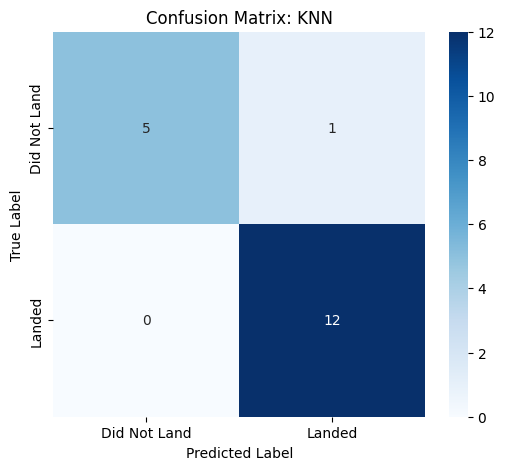

In [26]:
best_predictions = results[best_model_name]['predictions']
cm = confusion_matrix(Y_test, best_predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Did Not Land', 'Landed'],
            yticklabels=['Did Not Land', 'Landed'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix: {best_model_name}')
plt.show()

**Explanation:**
- A confusion matrix compares actual outcomes (rows) against predicted outcomes (columns) for the
  test set.
- The top-left and bottom-right cells count correct predictions (true negatives and true
  positives); the other two cells count mistakes (false positives and false negatives).
- `sns.heatmap(..., annot=True, fmt='d', ...)` displays this as a color-coded grid with the actual
  counts printed in each cell.